<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Assignment_3_Nikitina_Natalia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Direct numerical search with 10,000 buyers:
  tier 1: q=0.01969061, t=0.07999126
  tier 2: q=0.08057795, t=0.18258599
  tier 3: q=0.18243660, t=0.30509770
  simulated profit=0.04082103

Clean optimized menu used in the solution:
  tier 1: q=0.02040816, t=0.08163265
  tier 2: q=0.08163265, t=0.18367347
  tier 3: q=0.18367347, t=0.30612245
  Pi_discrete=0.04081633
  Pi_opt=0.04166667
  efficiency ratio=0.97959184


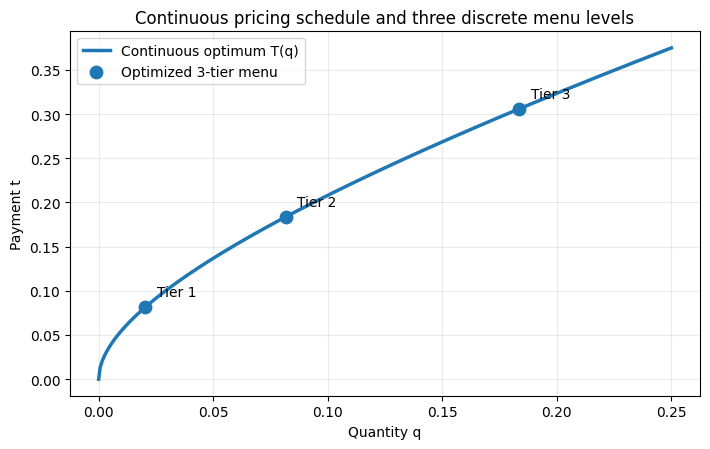

In [3]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "./.mplconfig")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize


N_BUYERS = 10_000
PI_OPT = 1 / 24


def continuous_price(q):
    q = np.asarray(q)
    return 0.5 * q + 0.5 * np.sqrt(q)


def simulate_profit(params, theta=None):
    """Очікуваний прибуток 3-рівневого меню на 10 000 типах покупців."""
    if theta is None:
        theta = (np.arange(N_BUYERS) + 0.5) / N_BUYERS

    q = np.asarray(params[:3], dtype=float)
    t = np.asarray(params[3:], dtype=float)
    utilities = theta[:, None] * np.sqrt(np.maximum(q, 0.0))[None, :] - t[None, :]
    all_utilities = np.column_stack([np.zeros(theta.size), utilities])
    choices = np.argmax(all_utilities, axis=1) - 1

    profit = np.zeros(theta.size)
    bought = choices >= 0
    profit[bought] = t[choices[bought]] - q[choices[bought]]
    return profit.mean()


def optimize_direct_menu():
    bounds = [(0.0, 0.25)] * 3 + [(0.0, 0.5)] * 3
    objective = lambda x: -simulate_profit(x)

    result = differential_evolution(
        objective,
        bounds,
        seed=11,
        popsize=12,
        maxiter=250,
        tol=1e-7,
        atol=1e-8,
        polish=False,
    )

    polished = minimize(
        objective,
        result.x,
        method="Nelder-Mead",
        options={"maxiter": 5000, "xatol": 1e-10, "fatol": 1e-10},
    )

    params = polished.x if polished.fun <= result.fun else result.x
    q = np.asarray(params[:3])
    t = np.asarray(params[3:])
    order = np.argsort(q)
    return q[order], t[order], -min(polished.fun, result.fun)


def exact_three_tier_menu():
    q = np.array([1 / 49, 4 / 49, 9 / 49])
    t = np.array([4 / 49, 9 / 49, 15 / 49])
    pi_discrete = 2 / 49
    return q, t, pi_discrete


def make_plot(q, t, path):
    grid = np.linspace(0, 0.25, 400)

    plt.figure(figsize=(7.2, 4.6))
    plt.plot(grid, continuous_price(grid), linewidth=2.5, label="Continuous optimum T(q)")
    plt.scatter(q, t, s=80, zorder=3, label="Optimized 3-tier menu")

    for i, (qi, ti) in enumerate(zip(q, t), 1):
        plt.annotate(f"Tier {i}", (qi, ti), xytext=(8, 8), textcoords="offset points")

    plt.xlabel("Quantity q")
    plt.ylabel("Payment t")
    plt.title("Continuous pricing schedule and three discrete menu levels")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=200)


if __name__ == "__main__":
    q_num, t_num, pi_num = optimize_direct_menu()
    q, t, pi_discrete = exact_three_tier_menu()

    print("Direct numerical search with 10,000 buyers:")
    for i, (qi, ti) in enumerate(zip(q_num, t_num), 1):
        print(f"  tier {i}: q={qi:.8f}, t={ti:.8f}")
    print(f"  simulated profit={pi_num:.8f}")

    print("\nClean optimized menu used in the solution:")
    for i, (qi, ti) in enumerate(zip(q, t), 1):
        print(f"  tier {i}: q={qi:.8f}, t={ti:.8f}")

    print(f"  Pi_discrete={pi_discrete:.8f}")
    print(f"  Pi_opt={PI_OPT:.8f}")
    print(f"  efficiency ratio={pi_discrete / PI_OPT:.8f}")

    make_plot(q, t, "/content/exercise4_pricing_schedule.png")
